In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Import and Explore Data

In [2]:
## read in the data provided

DF = pd.read_csv(r'GeneratedEmployeeData.csv')

In [3]:
#Identify the dataset’s number of records (i.e., rows) and number of variables (i.e., columns).
DF.shape

(13200, 16)

In [4]:
#List each variable and indicate the variable’s data type (quantitative/numerical or qualitative/categorical) and data subtype (i.e., continuous/discrete or nominal/ordinal).
DF.dtypes

EmployeeNumber                    int64
Age                               int64
Tenure                            int64
Turnover                         object
HourlyRate                       object
HoursWeekly                       int64
CompensationType                 object
AnnualSalary                     object
DrivingCommuterDistance           int64
JobRoleArea                      object
Gender                           object
MaritalStatus                    object
NumCompaniesPreviouslyWorked    float64
AnnualProfessionalDevHrs        float64
PaycheckMethod                   object
TextMessageOptIn                 object
dtype: object

In [5]:
#Identify a sample of observable values for each variable.
DF.head()

,EmployeeNumber,Age,Tenure,Turnover,HourlyRate,HoursWeekly,CompensationType,AnnualSalary,DrivingCommuterDistance,JobRoleArea,Gender,MaritalStatus,NumCompaniesPreviouslyWorked,AnnualProfessionalDevHrs,PaycheckMethod,TextMessageOptIn
0,13193,22,19,No,$76.84,40,Salary,"$215,016.37",-236,Human_Resources,Male,Single,8.0,16.0,Mail Check,Yes
1,13245,54,40,No,$25.38,40,Salary,"($8,471.17)",-477,Human_Resources,Prefer Not to Answer,Divorced,1.0,8.0,Mail Check,No
2,13058,49,8,No,$80.83,40,Salary,"($407,954.62)",343,Sales,Male,Single,3.0,20.0,DirectDeposit,Yes
3,17114,51,31,Yes,$49.72,40,Salary,"$435,098.54",457,Research,Prefer Not to Answer,Married,4.0,4.0,Mail_Check,NaN
4,16994,47,23,Yes,$58.24,40,Salary,"($43,563.57)",472,Marketing,Male,Single,8.0,23.0,Direct Deposit,Yes


In [6]:
#identify how many duplicates

DF.duplicated().sum()

6300

In [7]:
# find null values

DF.isnull().sum()

EmployeeNumber                     0
Age                                0
Tenure                             0
Turnover                           0
HourlyRate                         0
HoursWeekly                        0
CompensationType                   0
AnnualSalary                       0
DrivingCommuterDistance            0
JobRoleArea                        0
Gender                             0
MaritalStatus                      0
NumCompaniesPreviouslyWorked    1347
AnnualProfessionalDevHrs         456
PaycheckMethod                     0
TextMessageOptIn                4462
dtype: int64

In [8]:
# find non-null missing values, inconsistent entries, and formatting errors
## note there is an error at the end of this cell -- that was left in as part of the exploration phase 
## -- it tells us there is something amiss with the last column

for col in DF.columns:
    print(f"\n==={col}===")
    print(np.sort(DF[col].unique()))


===EmployeeNumber===
[10001 10003 10009 ... 29992 29993 29997]

===Age===
[18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41
 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65]

===Tenure===
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47]

===Turnover===
['No' 'Yes']

===HourlyRate ===
['$17.01 ' '$17.04 ' '$17.06 ' ... '$99.92 ' '$99.93 ' '$99.95 ']

===HoursWeekly===
[40]

===CompensationType===
['Salary']

===AnnualSalary===
['$10,155.57 ' '$10,393.48 ' '$100,134.07 ' ... '($97,791.19)'
 '($99,214.06)' '($99,994.03)']

===DrivingCommuterDistance===
[-500 -499 -498 -497 -496 -495 -494 -493 -492 -490 -489 -487 -486 -484
 -483 -482 -481 -480 -479 -478 -477 -476 -475 -473 -472 -471 -470 -469
 -466 -465 -464 -463 -462 -461 -460 -459 -458 -457 -455 -454 -451 -450
 -449 -448 -446 -444 -443 -442 -441 -440 -439 -437 -436 -435 -434 -433
 -432 -431 -430 -

TypeError: '<' not supported between instances of 'float' and 'str'

In [ ]:
# check employee number specifically for duplicates

DF['EmployeeNumber'].duplicated().sum()

In [9]:
# check column names for data entry errors 

DF.columns

Index(['EmployeeNumber', 'Age', 'Tenure', 'Turnover', 'HourlyRate ',
       'HoursWeekly', 'CompensationType', 'AnnualSalary',
       'DrivingCommuterDistance', 'JobRoleArea', 'Gender', 'MaritalStatus',
       'NumCompaniesPreviouslyWorked', 'AnnualProfessionalDevHrs',
       'PaycheckMethod', 'TextMessageOptIn'],
      dtype='object')

# Fix Duplicate Entries, Inconsistent Data, and Formatting Errors

In [10]:
#remove exact duplicates

DF.drop_duplicates(inplace=True)
DF.shape

(6900, 16)

In [11]:
## where there are two employee records, one is Turnover "Yes" and one is Turnover "No", keep the "No" record
mixed_ids = (
    DF.groupby("EmployeeNumber")["Turnover"]
      .nunique()
      .loc[lambda x: x == 2]
      .index
)

DF_mixed = DF[DF["EmployeeNumber"].isin(mixed_ids)]

DF_other = DF[~DF["EmployeeNumber"].isin(mixed_ids)]

DF_mixed = (
    DF_mixed
    .sort_values("Turnover")
    .drop_duplicates("EmployeeNumber", keep="first")
)

DF2 = pd.concat([DF_other, DF_mixed]).sort_index()

In [12]:
## add trailing zero to younger employee
duplicate_ids = (
    DF2.groupby("EmployeeNumber")
      .filter(lambda x: len(x) == 2 and x["Turnover"].nunique() == 1)
      ["EmployeeNumber"]
      .unique()
)
mask = DF2["EmployeeNumber"].isin(duplicate_ids)

younger = (
    DF2.loc[mask]
      .groupby("EmployeeNumber")["Age"]
      .transform("min")
)

DF2.loc[mask & DF2["Age"].eq(younger), "EmployeeNumber"] = (
    DF2.loc[mask & DF2["Age"].eq(younger), "EmployeeNumber"].astype(str) + "0"
)

In [13]:
## fix employee number type back to integer
DF2["EmployeeNumber"] = DF2["EmployeeNumber"].astype(int)

In [14]:
##remaining multiple versions were assigned unique id because the synthetic data provides no basis for 
##determining a true record beyond above methods of isolating active employees 
##and assuming the newer record lost a zero
fine = DF2[~DF2.duplicated(subset=["EmployeeNumber"], keep=False)].sort_values("EmployeeNumber")
sp = DF2[DF2.duplicated(subset=["EmployeeNumber"], keep=False)].sort_values("EmployeeNumber")

sp["EmployeeVersion"] = sp.groupby("EmployeeNumber").cumcount()

sp["EmployeeID_Clean"] = (
    sp["EmployeeNumber"].astype(str)
    + sp["EmployeeVersion"].astype(str)
)
sp.drop(columns={'EmployeeVersion','EmployeeNumber'},inplace=True)
sp.rename(columns={'EmployeeID_Clean':'EmployeeNumber'},inplace=True)
DF3 = pd.concat([fine,sp])

In [15]:
## fix employee number type back to integer
DF3["EmployeeNumber"] = DF3["EmployeeNumber"].astype(int)

In [16]:
#confirm no longer duplicates on employee number
DF3[DF3.duplicated(subset=["EmployeeNumber"], keep=False)].sort_values("EmployeeNumber")

,EmployeeNumber,Age,Tenure,Turnover,HourlyRate,HoursWeekly,CompensationType,AnnualSalary,DrivingCommuterDistance,JobRoleArea,Gender,MaritalStatus,NumCompaniesPreviouslyWorked,AnnualProfessionalDevHrs,PaycheckMethod,TextMessageOptIn


In [17]:
# fix column name for Hourly rate

DF3.rename(columns={'HourlyRate ':'HourlyRate'},inplace=True)

In [18]:
# remove str values from numeric

DF3['HourlyRate'] = DF3['HourlyRate'].str.replace('$', '', regex=False).str.replace(',', '', regex=False)

In [19]:
# convert column to float (continuous numeric)

DF3['HourlyRate'] = DF3['HourlyRate'].astype(float)

In [20]:
# verify column was cleaned correctly

DF3['HourlyRate'].unique()

array([58.14, 38.11, 88.79, ..., 70.08, 59.89, 26.2 ])

In [21]:
## we know hourlyrate is correct but annual salary may not be, re-calculate annual salary to match hourly rate
## we know they work 40 hours a week and are paid at their hourly rate, even when on PTO. 

In [22]:
DF3['AnnualSalary_Calc'] = DF3['HourlyRate']*40*52

In [23]:
np.sort(DF3['AnnualSalary_Calc'].unique())

array([ 35380.8,  35443.2,  35484.8, ..., 207833.6, 207854.4, 207896. ])

In [24]:
DF3.drop(columns={'AnnualSalary'},inplace=True)

In [25]:
# isolate nevative commute times to count them

NegCommute = DF3[DF3['DrivingCommuterDistance'] < 0]
NegCommute.shape

(643, 16)

In [26]:
#take the absolute value of the column to remove the negatives, which are data errors
DF3['DrivingCommuterDistance'] = DF3['DrivingCommuterDistance'].abs()
#ensure it worked as expected
np.sort(DF3['DrivingCommuterDistance'].unique())

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [27]:
#recount null values, fixed in next section
DF3['NumCompaniesPreviouslyWorked'].isna().sum()

656

In [28]:
#recount null values , fixed in next section
DF3['AnnualProfessionalDevHrs'].isna().sum()

221

In [29]:
# fix inconsistent entries of Paycheck Method due to punctuation differences 

DF3['PaycheckMethod'] = np.where(DF3['PaycheckMethod'] == 'DirectDeposit','Direct Deposit',DF3['PaycheckMethod'])
DF3['PaycheckMethod'] = np.where(DF3['PaycheckMethod'] == 'Direct_Deposit','Direct Deposit',DF3['PaycheckMethod'])
DF3['PaycheckMethod'] = np.where(DF3['PaycheckMethod'] == 'Mail Check','Mailed Check',DF3['PaycheckMethod'])
DF3['PaycheckMethod'] = np.where(DF3['PaycheckMethod'] == 'Mail_Check','Mailed Check',DF3['PaycheckMethod'])
DF3['PaycheckMethod'] = np.where(DF3['PaycheckMethod'] == 'MailedCheck','Mailed Check',DF3['PaycheckMethod'])
DF3['PaycheckMethod'].unique()

array(['Direct Deposit', 'Mailed Check'], dtype=object)

In [30]:
# Fix error from loop above 

DF3['TextMessageOptIn'] = DF3['TextMessageOptIn'].astype(str)

In [31]:
# re run check for non-null missing values, inconsistent entries, and formatting errors

np.sort(DF3['TextMessageOptIn'].unique())

array(['No', 'Yes', 'nan'], dtype=object)

In [32]:
#isolate 'nan's to count them

NanText = DF3[DF3['TextMessageOptIn'] == 'nan']
NanText.shape

(2146, 16)

# Check for and Resolve Outliers

In [33]:
#create box plots for each column to check for outliers in numeric columns

In [34]:
#isolate numeric columns
dType = pd.DataFrame(DF3.dtypes)
dType.reset_index(inplace=True)
dType2 = dType[dType[0] != 'object']
dType2

,index,0
0,EmployeeNumber,int64
1,Age,int64
2,Tenure,int64
4,HourlyRate,float64
5,HoursWeekly,int64
7,DrivingCommuterDistance,int64
11,NumCompaniesPreviouslyWorked,float64
12,AnnualProfessionalDevHrs,float64
15,AnnualSalary_Calc,float64


In [35]:
##skip Employee Number -- not actually a numeric column even though its an integer 
#-- it is a qualititative unique ID column
##skip hours weekly, we know its a constant

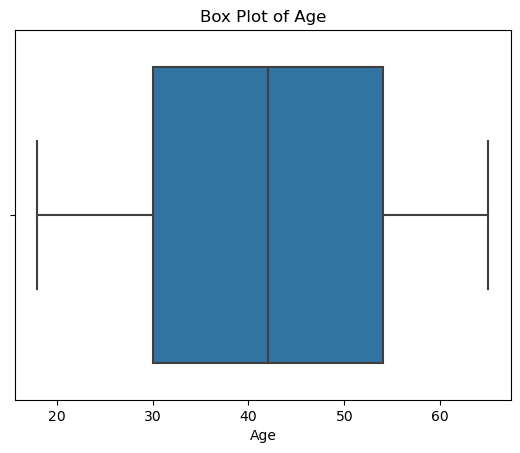

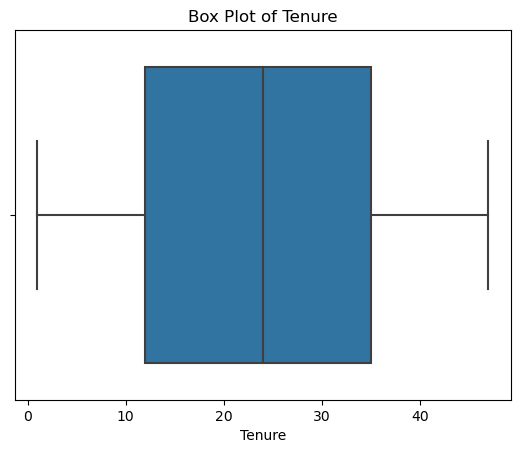

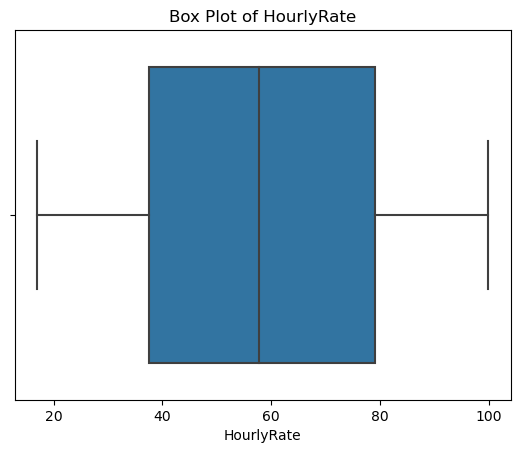

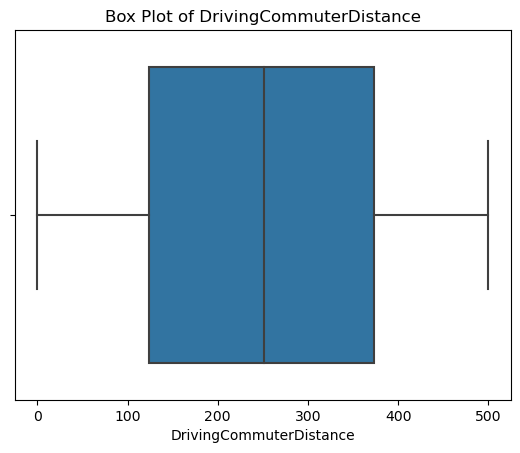

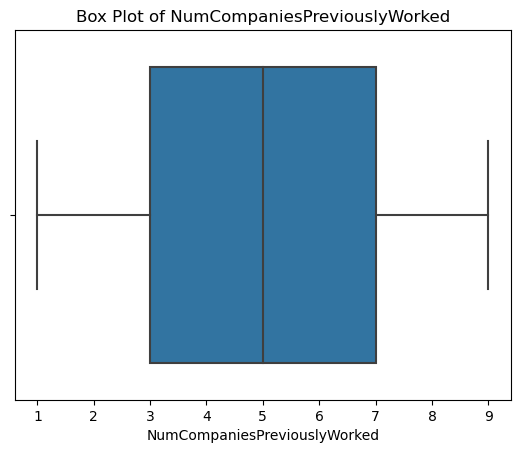

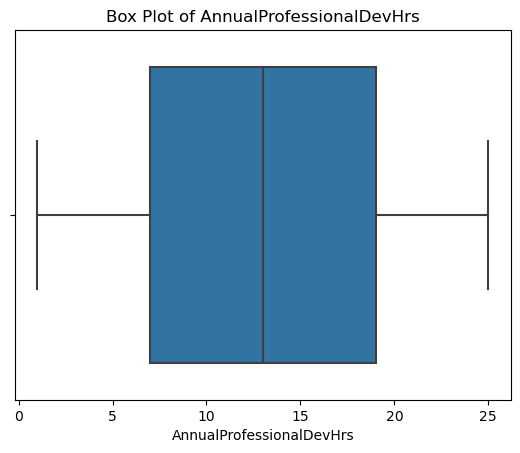

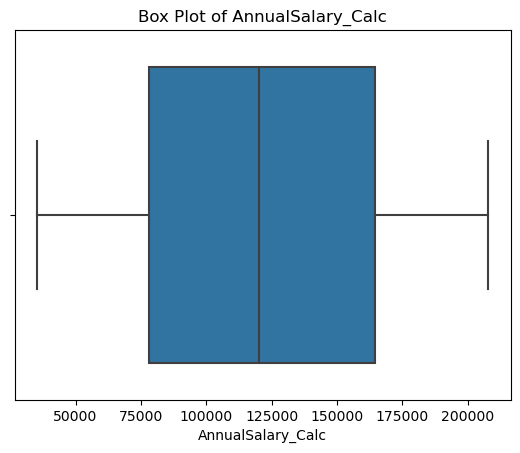

In [36]:
%matplotlib inline

numeric_cols = DF3.select_dtypes(include="number").columns.drop(
    ["EmployeeNumber", "HoursWeekly"]
)

for col in numeric_cols:
    fig, ax = plt.subplots()
    sns.boxplot(x=DF3[col], ax=ax)
    ax.set_title(f"Box Plot of {col}")
    plt.show()

In [37]:
## no outliers to cap

# Resolve Missing Data

In [38]:
#turn 'nan' to 'No' for data consistency

DF3['TextMessageOptIn'] = DF3['TextMessageOptIn'].replace('nan', 'No')
DF3['TextMessageOptIn'].unique()

array(['No', 'Yes'], dtype=object)

In [39]:
#===NumCompaniesPreviouslyWorked===
#[ 1.  2.  3.  4.  5.  6.  7.  8.  9. nan]

#===AnnualProfessionalDevHrs===
#[ 5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20. 21. 22.
# 23. 24. 25. nan]

In [40]:
#Impute 100 for nan for columns NumCompaniesPreviouslyWorked & AnnualProfessionalDevHrs then cap the outliers
#not using 0 or stat like mean/median/mode so as not to introduce false data
#can't leave as nan as downstream systems cannot handle null values

In [41]:
DF3['NumCompaniesPreviouslyWorked'] = DF3['NumCompaniesPreviouslyWorked'].replace(np.nan, 100)
DF3['NumCompaniesPreviouslyWorked'].unique()

array([  7.,   9.,   4.,   8., 100.,   5.,   2.,   3.,   1.,   6.])

In [42]:
DF3['AnnualProfessionalDevHrs'] = DF3['AnnualProfessionalDevHrs'].replace(np.nan, 100)
DF3['AnnualProfessionalDevHrs'].unique()

array([ 23.,  18.,   5.,  20.,  11.,  19.,  15.,  21.,   8.,   7.,  17.,
        12.,   2.,  24.,   4., 100.,  16.,   6.,   9.,  10.,  22.,  25.,
         1.,  13.,   3.,  14.])

656


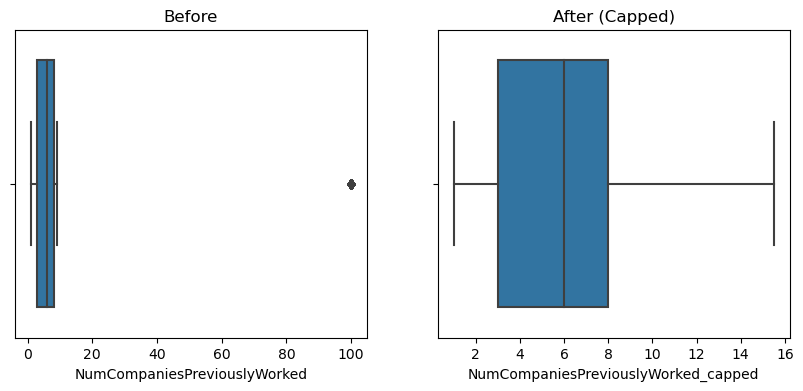

(None, None)

In [43]:
# define and cap the outliers found

Q1 = DF3['NumCompaniesPreviouslyWorked'].quantile(0.25)
Q3 = DF3['NumCompaniesPreviouslyWorked'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

DF3['NumCompaniesPreviouslyWorked_capped'] = DF3['NumCompaniesPreviouslyWorked'].clip(lower=lower_bound, upper=upper_bound)

num_capped = ((DF3['NumCompaniesPreviouslyWorked'] < lower_bound) | 
              (DF3['NumCompaniesPreviouslyWorked'] > upper_bound)).sum()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=DF3['NumCompaniesPreviouslyWorked'])
plt.title('Before')

plt.subplot(1,2,2)
sns.boxplot(x=DF3['NumCompaniesPreviouslyWorked_capped'])
plt.title('After (Capped)')

print(num_capped),plt.show()

221


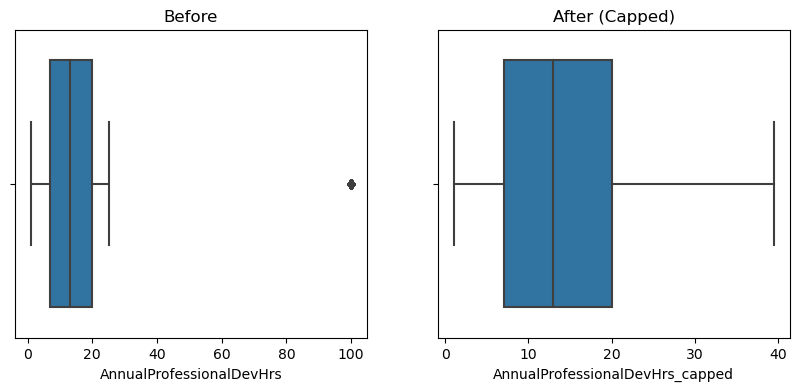

(None, None)

In [44]:
# define and cap the outliers found

Q1 = DF3['AnnualProfessionalDevHrs'].quantile(0.25)
Q3 = DF3['AnnualProfessionalDevHrs'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

DF3['AnnualProfessionalDevHrs_capped'] = DF3['AnnualProfessionalDevHrs'].clip(lower=lower_bound, upper=upper_bound)

num_capped = ((DF3['AnnualProfessionalDevHrs'] < lower_bound) | 
              (DF3['AnnualProfessionalDevHrs'] > upper_bound)).sum()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=DF3['AnnualProfessionalDevHrs'])
plt.title('Before')

plt.subplot(1,2,2)
sns.boxplot(x=DF3['AnnualProfessionalDevHrs_capped'])
plt.title('After (Capped)')

print(num_capped),plt.show()

In [45]:
DF3.columns

Index(['EmployeeNumber', 'Age', 'Tenure', 'Turnover', 'HourlyRate',
       'HoursWeekly', 'CompensationType', 'DrivingCommuterDistance',
       'JobRoleArea', 'Gender', 'MaritalStatus',
       'NumCompaniesPreviouslyWorked', 'AnnualProfessionalDevHrs',
       'PaycheckMethod', 'TextMessageOptIn', 'AnnualSalary_Calc',
       'NumCompaniesPreviouslyWorked_capped',
       'AnnualProfessionalDevHrs_capped'],
      dtype='object')

In [46]:
#drop uncapped outlier columns

In [49]:
DF4 = DF3[['EmployeeNumber', 'Age', 'Tenure', 'Turnover', 'HourlyRate',
       'HoursWeekly', 'CompensationType', 'AnnualSalary_Calc',
       'DrivingCommuterDistance', 'JobRoleArea', 'Gender', 'MaritalStatus',
       'NumCompaniesPreviouslyWorked_capped', 'AnnualProfessionalDevHrs_capped',
       'PaycheckMethod', 'TextMessageOptIn']].copy()

In [50]:
## employees cannot start working until they are 18, a 19 year old can therefore have at most 1 year of tenure
## evaluate and resolve tenure numbers that do not make sense

In [51]:
DF4["AgeMinusTenure"] = DF4["Age"] - DF4["Tenure"]

In [52]:
## when age minus tenure > 18, keep
## when age minus tenure > 0 < 18, replace tenure with age minus tenure
## when age minus tenure <0, replace tenure with 0
DF4["Tenure_Calc"] = np.where(DF4["Age"] - DF4["Tenure"] >= 18, DF4["Tenure"],                     
    np.where(DF4["Age"] - DF4["Tenure"] > 0, DF4["Age"] - DF4["Tenure"],
        0                            
    )
)

In [53]:
DF4.head()

,EmployeeNumber,Age,Tenure,Turnover,HourlyRate,HoursWeekly,CompensationType,AnnualSalary_Calc,DrivingCommuterDistance,JobRoleArea,Gender,MaritalStatus,NumCompaniesPreviouslyWorked_capped,AnnualProfessionalDevHrs_capped,PaycheckMethod,TextMessageOptIn,AgeMinusTenure,Tenure_Calc
5591,10001,40,41,No,58.14,40,Salary,120931.2,340,Marketing,Male,Single,7.0,23.0,Direct Deposit,No,-1,0
2649,10003,19,36,Yes,38.11,40,Salary,79268.8,27,Manufacturing,Prefer Not to Answer,Married,9.0,18.0,Mailed Check,No,-17,0
4724,10009,37,39,Yes,88.79,40,Salary,184683.2,229,InformationTechnology,Prefer Not to Answer,Divorced,4.0,5.0,Direct Deposit,No,-2,0
3367,10013,43,11,Yes,43.21,40,Salary,89876.8,124,Information Technology,Male,Divorced,8.0,20.0,Mailed Check,Yes,32,11
815,10014,52,40,Yes,84.60,40,Salary,175968.0,251,Information Technology,Male,Married,15.5,11.0,Mailed Check,No,12,12


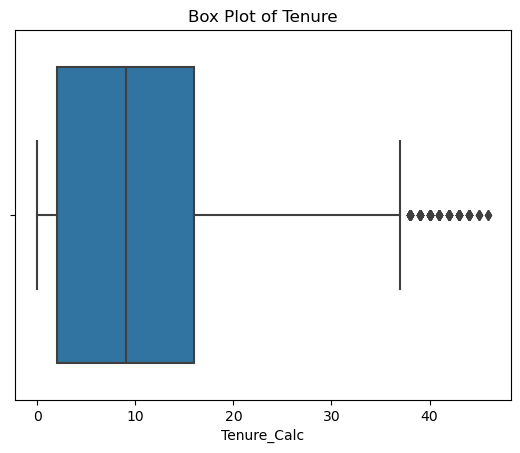

In [54]:
#check for outliers in revised data
fig, ax = plt.subplots()
sns.boxplot(x=DF4["Tenure_Calc"], ax=ax)
ax.set_title("Box Plot of Tenure")
plt.show()

149


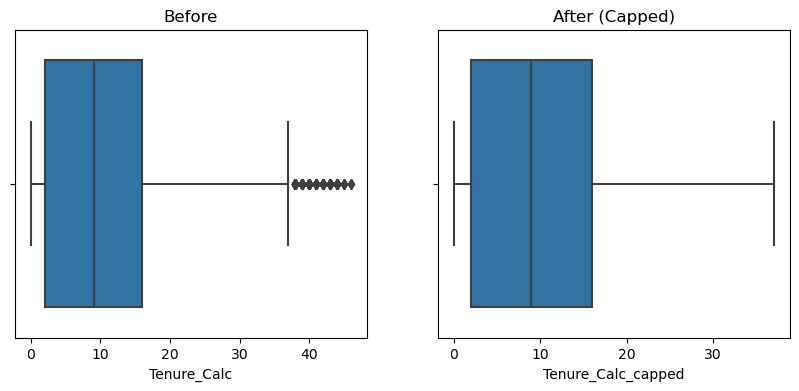

(None, None)

In [55]:
# define and cap the outliers found

Q1 = DF4['Tenure_Calc'].quantile(0.25)
Q3 = DF4['Tenure_Calc'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

DF4['Tenure_Calc_capped'] = DF4['Tenure_Calc'].clip(lower=lower_bound, upper=upper_bound)

num_capped = ((DF4['Tenure_Calc'] < lower_bound) | 
              (DF4['Tenure_Calc'] > upper_bound)).sum()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=DF4['Tenure_Calc'])
plt.title('Before')

plt.subplot(1,2,2)
sns.boxplot(x=DF4['Tenure_Calc_capped'])
plt.title('After (Capped)')

print(num_capped),plt.show()

In [56]:
DF5 = DF4.drop(columns={'Tenure_Calc','Tenure','AgeMinusTenure'})

In [57]:
DF5.head()

,EmployeeNumber,Age,Turnover,HourlyRate,HoursWeekly,CompensationType,AnnualSalary_Calc,DrivingCommuterDistance,JobRoleArea,Gender,MaritalStatus,NumCompaniesPreviouslyWorked_capped,AnnualProfessionalDevHrs_capped,PaycheckMethod,TextMessageOptIn,Tenure_Calc_capped
5591,10001,40,No,58.14,40,Salary,120931.2,340,Marketing,Male,Single,7.0,23.0,Direct Deposit,No,0
2649,10003,19,Yes,38.11,40,Salary,79268.8,27,Manufacturing,Prefer Not to Answer,Married,9.0,18.0,Mailed Check,No,0
4724,10009,37,Yes,88.79,40,Salary,184683.2,229,InformationTechnology,Prefer Not to Answer,Divorced,4.0,5.0,Direct Deposit,No,0
3367,10013,43,Yes,43.21,40,Salary,89876.8,124,Information Technology,Male,Divorced,8.0,20.0,Mailed Check,Yes,11
815,10014,52,Yes,84.60,40,Salary,175968.0,251,Information Technology,Male,Married,15.5,11.0,Mailed Check,No,12


In [58]:
DF5.to_csv(r'CleanedDataSet.csv')